# Reproducing the parent paper's figures

Patil, K. P. and Kapfhamme, G. (2022). *Machine Learning Meets Sports: Data
Analytics Demonstrating the Relationship Between Playing Surface & the
Injury/Performance of Athletes.* IJERT Vol. 11 Issue 08.
https://www.ijert.org/research/machine-learning-meets-sports-IJERTV11IS080140.pdf

The parent paper does not publish its own code. This notebook rebuilds each
of its eight figures directly from the raw Kaggle "NFL 1st and Future -
Analytics" files it uses. Run the cells top to bottom -- the two "prepare
data" cells do the heavy lifting once, and each figure cell after that is
quick and can be re-run on its own.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# seaborn's stripplot jitter draws from the global numpy RNG, so seed it to
# keep regenerated figures identical between runs
np.random.seed(0)

DATA_DIR = "../data/raw"
INJURY_PATH = f"{DATA_DIR}/InjuryRecord.csv"
PLAYLIST_PATH = f"{DATA_DIR}/PlayList.csv"
TRACK_PATH = f"{DATA_DIR}/PlayerTrackData.csv"
TRACK_CHUNKSIZE = 2_000_000

## Load data

`InjuryRecord.csv` and `PlayList.csv` are small enough to load in full.

In [2]:
injury = pd.read_csv(INJURY_PATH)
playlist = pd.read_csv(PLAYLIST_PATH)

print("injury:", injury.shape)
print("playlist:", playlist.shape)
injury.head()

injury: (105, 9)
playlist: (267005, 14)


,PlayerKey,GameID,PlayKey,BodyPart,Surface,DM_M1,DM_M7,DM_M28,DM_M42
0,39873,39873-4,39873-4-32,Knee,Synthetic,1,1,1,1
1,46074,46074-7,46074-7-26,Knee,Natural,1,1,0,0
2,36557,36557-1,36557-1-70,Ankle,Synthetic,1,1,1,1
3,46646,46646-3,46646-3-30,Ankle,Natural,1,0,0,0
4,43532,43532-5,43532-5-69,Ankle,Synthetic,1,1,1,1


## FIG-1: Injury rate (%) by field type

`injury rate (%) = injuries on surface / plays on surface * 100`. The paper
reports synthetic surfaces at roughly 1.8x the injury rate of natural
surfaces.

synthetic=0.052%  natural=0.031%  ratio=1.69x


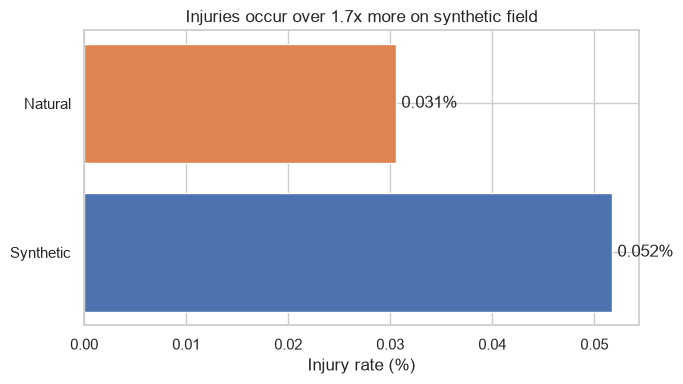

In [3]:
plays_by_surface = playlist["FieldType"].value_counts()
injuries_by_surface = injury["Surface"].value_counts()
rate = (injuries_by_surface / plays_by_surface * 100).reindex(["Synthetic", "Natural"])
ratio = rate["Synthetic"] / rate["Natural"]

print(f"synthetic={rate['Synthetic']:.3f}%  natural={rate['Natural']:.3f}%  ratio={ratio:.2f}x")

plt.figure(figsize=(7, 4))
bars = plt.barh(rate.index, rate.values, color=["#4C72B0", "#DD8452"])
plt.xlabel("Injury rate (%)")
plt.title(f"Injuries occur over {ratio:.1f}x more on synthetic field")
for bar, value in zip(bars, rate.values):
    plt.text(value, bar.get_y() + bar.get_height() / 2, f" {value:.3f}%", va="center")
plt.tight_layout()
plt.show()

## FIG-2: Injury severity -- players by days-away-from-play bucket

`DM_M1` / `DM_M7` / `DM_M28` / `DM_M42` each flag whether the player was
still out at that many days post-injury, split by surface.

**Note on counts vs. the paper.** Our bars are far lower than the paper's.
The paper's FIG-2 reports 239 synthetic / 198 natural in the 1-day bucket
alone — 437 injured players — but `InjuryRecord.csv` contains only **105
injuries in total** (57 synthetic, 48 natural), which is the entire injury
population the NFL released for this competition. No bucket can exceed 105.

We tested the plausible ways the larger numbers might arise and none
reproduce them: counting distinct players gives 56/46; taking `FieldType`
from `PlayList` instead of `Surface` gives 41/36; expanding each injury to
every play of its game overshoots to 1933/1470. The paper's absolute counts
are therefore not reproducible from the official dataset. What *does*
reproduce is the direction and the relative pattern — synthetic exceeds
natural in every bucket, and the gap widens for longer absences.

         Synthetic  Natural
1 Day           57       48
7 Days          41       35
28 Days         22       15
42 Days         16       13


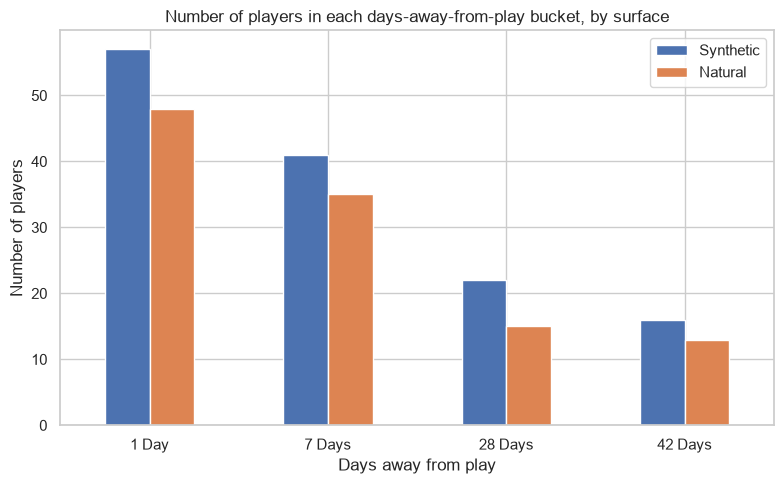

In [4]:
buckets = ["DM_M1", "DM_M7", "DM_M28", "DM_M42"]
labels = ["1 Day", "7 Days", "28 Days", "42 Days"]

counts = pd.DataFrame({
    "Synthetic": [injury.loc[injury["Surface"] == "Synthetic", b].sum() for b in buckets],
    "Natural": [injury.loc[injury["Surface"] == "Natural", b].sum() for b in buckets],
}, index=labels)
print(counts)

ax = counts.plot(kind="bar", figsize=(8, 5), color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Number of players")
ax.set_xlabel("Days away from play")
ax.set_title("Number of players in each days-away-from-play bucket, by surface")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## FIG-3: Skew toward synthetic turf, by days-away-from-play bucket

The paper labels this the *"percentage of higher numbers players injured in
Artificial Turf ... compare to Natural Turf"* and publishes the values
**9 / 16 / 39 / 40**.

Those values are **not** the relative increase `(syn - nat) / nat` — on the
paper's own FIG-2 counts that formula gives 21 / 39 / 127 / 136. They are
reproduced exactly by the synthetic *share* of each bucket above even:

`(syn - nat) / (syn + nat) * 100` → 9.4 / 16.2 / 38.8 / 40.5

So the paper's prose ("40% higher number of injured players") mislabels a
share difference as a relative increase. We implement the paper's actual
formula here so the figure is method-comparable.

1 Day       8.571429
7 Days      7.894737
28 Days    18.918919
42 Days    10.344828
dtype: float64


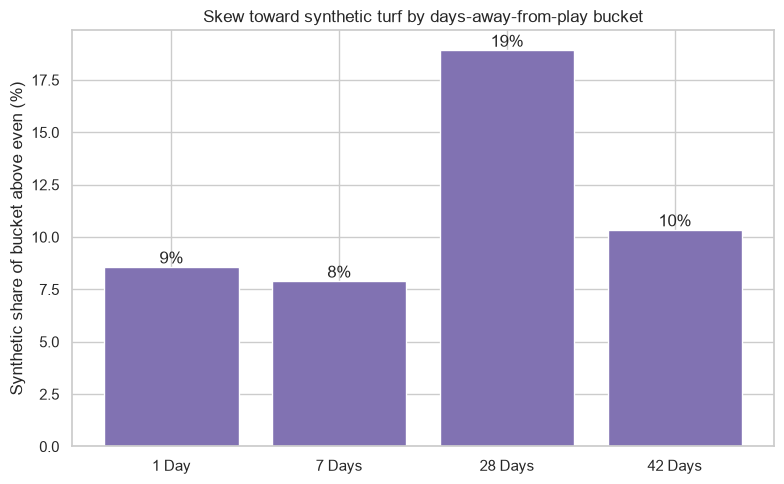

In [5]:
share_diff = (counts["Synthetic"] - counts["Natural"]) / (counts["Synthetic"] + counts["Natural"]) * 100
print(share_diff)

plt.figure(figsize=(8, 5))
plt.bar(labels, share_diff.values, color="#8172B2")
plt.ylabel("Synthetic share of bucket above even (%)")
plt.title("Skew toward synthetic turf by days-away-from-play bucket")
for i, value in enumerate(share_diff.values):
    plt.text(i, value, f"{value:.0f}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## Prepare tracking data (needed for FIG-4 through FIG-8)

`PlayerTrackData.csv` is ~4 GB / 76 million rows, so this cell streams it in
chunks rather than loading it all at once. In a single pass it collects:

- every raw tracking row belonging to one of the 77 injury plays that have a
  known `PlayKey` (used for FIG-4/5/6), and
- the per-play maximum speed and distance for **every** play in the dataset
  (used for FIG-7/8).

This is the slow cell (roughly 30-60 seconds depending on disk speed) --
everything after it is fast.

In [6]:
injury_with_key = injury.dropna(subset=["PlayKey"]).copy()
injury_keys = set(injury_with_key["PlayKey"])
print(f"{len(injury_with_key)} of {len(injury)} injuries have a PlayKey and can be located in the tracking data.")

injury_rows = []
play_max_parts = []

for chunk in pd.read_csv(TRACK_PATH, usecols=["PlayKey", "x", "y", "dis", "s"], chunksize=TRACK_CHUNKSIZE):
    mask = chunk["PlayKey"].isin(injury_keys)
    if mask.any():
        injury_rows.append(chunk.loc[mask])
    agg = chunk.groupby("PlayKey", sort=False).agg(max_s=("s", "max"), max_dis=("dis", "max"))
    play_max_parts.append(agg)

injury_track = pd.concat(injury_rows, ignore_index=True) if injury_rows else pd.DataFrame()
play_max = pd.concat(play_max_parts)
play_max = play_max.groupby("PlayKey", sort=False).agg(max_s=("max_s", "max"), max_dis=("max_dis", "max"))

print("injury_track rows:", len(injury_track))
print("play_max rows:", len(play_max))

77 of 105 injuries have a PlayKey and can be located in the tracking data.


injury_track rows: 21905
play_max rows: 266960


## FIG-4 / FIG-5: Injury type by field position, artificial vs. natural turf

Each injury play's mean x-position on the field, grouped by body part.
`Toes` and `Heel` are folded into `Foot` to match the paper's three-category
legend (Knee / Ankle / Foot).

In [7]:
body_part_map = {"Toes": "Foot", "Heel": "Foot"}
injury_with_key["BodyPartGroup"] = injury_with_key["BodyPart"].replace(body_part_map)

play_x = injury_track.groupby("PlayKey")["x"].mean().rename("mean_x")
merged_x = injury_with_key.merge(play_x, on="PlayKey", how="inner")

def plot_injury_type(surface, title):
    subset = merged_x[merged_x["Surface"] == surface]
    plt.figure(figsize=(8, 5))
    order = subset["BodyPartGroup"].value_counts().index
    sns.boxplot(data=subset, x="mean_x", y="BodyPartGroup", order=order, hue="BodyPartGroup", legend=False)
    sns.stripplot(data=subset, x="mean_x", y="BodyPartGroup", order=order, color="black", alpha=0.5, size=4)
    plt.xlabel("Field x-position (yards)")
    plt.ylabel("Body part")
    plt.title(title)
    plt.tight_layout()
    plt.show()

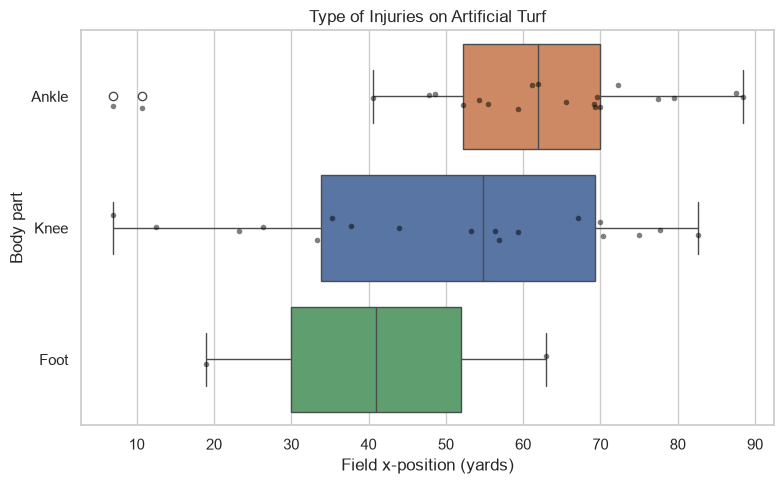

In [8]:
plot_injury_type("Synthetic", "Type of Injuries on Artificial Turf")

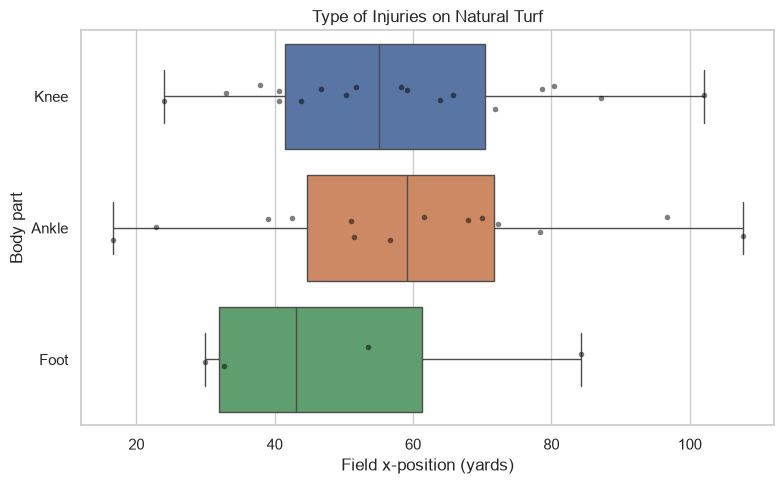

In [9]:
plot_injury_type("Natural", "Type of Injuries on Natural Turf")

## FIG-6: Injury field-location density, artificial vs. natural turf

In [10]:
play_xy = injury_track.groupby("PlayKey")[["x", "y"]].mean()
merged_xy = injury_with_key.merge(play_xy, on="PlayKey", how="inner")

def plot_injury_location(surface, title, cmap):
    subset = merged_xy[merged_xy["Surface"] == surface]
    plt.figure(figsize=(7, 5))
    sns.kdeplot(data=subset, x="x", y="y", fill=True, cmap=cmap, thresh=0.05)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.tight_layout()
    plt.show()

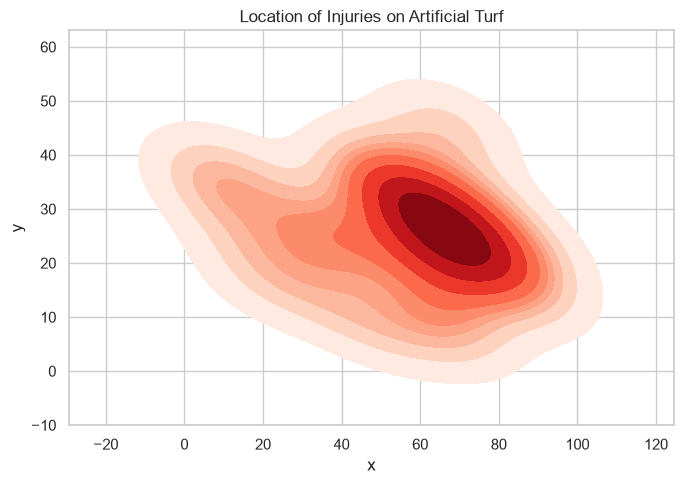

In [11]:
plot_injury_location("Synthetic", "Location of Injuries on Artificial Turf", "Reds")

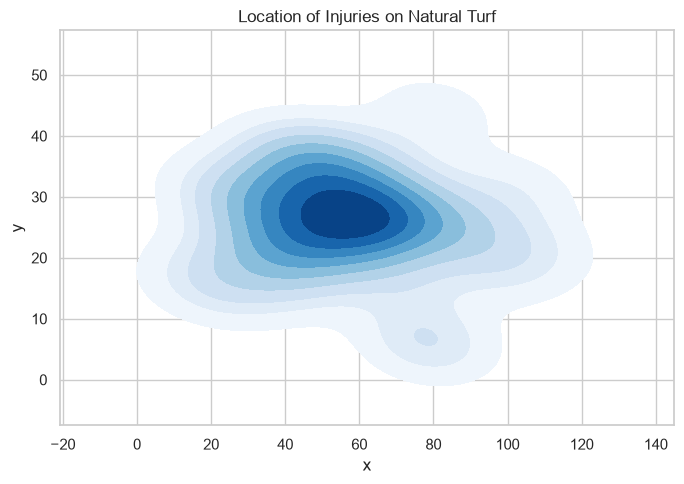

In [12]:
plot_injury_location("Natural", "Location of Injuries on Natural Turf", "Blues")

## FIG-7 / FIG-8: Max speed and max distance distributions, by surface

Computed across **all** plays (not just injury plays) using the `play_max`
table built above, joined back to `PlayList.csv` for each play's
`FieldType`.

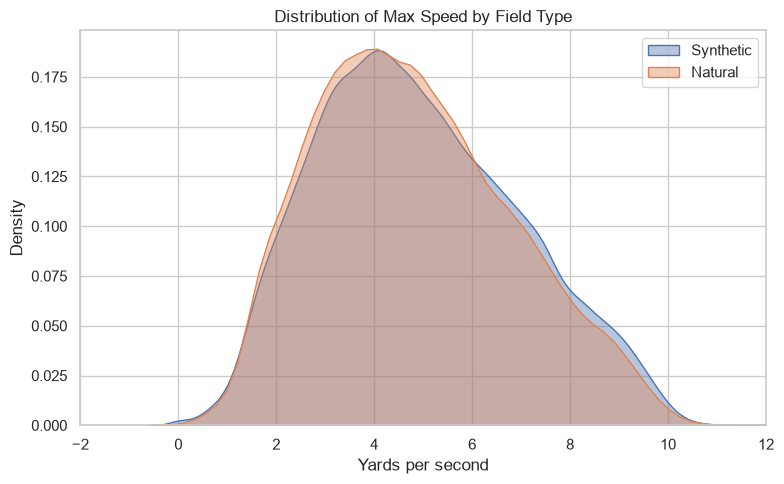

In [13]:
surface_lookup = playlist[["PlayKey", "FieldType"]].drop_duplicates("PlayKey")
play_max_surface = play_max.reset_index().merge(surface_lookup, on="PlayKey", how="inner")
play_max_surface = play_max_surface[play_max_surface["FieldType"].isin(["Synthetic", "Natural"])]

plt.figure(figsize=(8, 5))
for surface, color in [("Synthetic", "#4C72B0"), ("Natural", "#DD8452")]:
    sns.kdeplot(play_max_surface.loc[play_max_surface["FieldType"] == surface, "max_s"],
                label=surface, fill=True, alpha=0.4, color=color)
plt.xlabel("Yards per second")
plt.ylabel("Density")
plt.title("Distribution of Max Speed by Field Type")
# match the paper's FIG-7 axis; excludes 5 plays (0.002%) whose recorded
# max speed exceeds 12 yd/s, which are tracking artifacts
plt.xlim(-2, 12)
plt.xticks(np.arange(-2, 13, 2))
plt.legend()
plt.tight_layout()
plt.show()

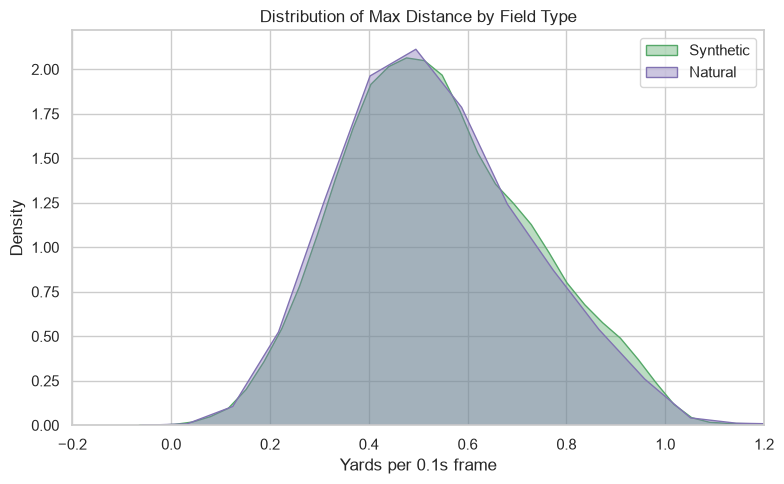

In [14]:
plt.figure(figsize=(8, 5))
for surface, color in [("Synthetic", "#55A868"), ("Natural", "#8172B2")]:
    sns.kdeplot(play_max_surface.loc[play_max_surface["FieldType"] == surface, "max_dis"],
                label=surface, fill=True, alpha=0.4, color=color)
plt.xlabel("Yards per 0.1s frame")
plt.ylabel("Density")
plt.title("Distribution of Max Distance by Field Type")
# match the paper's FIG-8 axis; excludes 0.6% of plays above 1.2 yards per
# frame, which correspond to the same tracking artifacts
plt.xlim(-0.2, 1.2)
plt.xticks(np.round(np.arange(-0.2, 1.21, 0.2), 1))
plt.legend()
plt.tight_layout()
plt.show()